# Original Data Exploration

email_batch_1_priority_qwen2.5.csv & email_batch_2_priority_qwen2.5.csv

In [1]:
import pandas as pd

# Load the datasets
email_batch_1 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/datasets/priority/Email Qwen Priority Dataset/email_batch_1_priority_qwen2.5.csv')
email_batch_2 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/datasets/priority/Email Qwen Priority Dataset/email_batch_2_priority_qwen2.5.csv')

email_data = pd.concat([email_batch_1, email_batch_2], ignore_index=True)

Total 2 batches Priority Level using Qwen2.5

In [4]:
# Display frequency counts for batch 1
print("Frequency of priority levels in batch 1:")
print(email_batch_1['Email_Priority'].value_counts())
# Display frequency counts for batch 2
print("\nFrequency of priority levels in batch 2:")
print(email_batch_2['Email_Priority'].value_counts())

print("\nFrequency of combined priority levels:")
print(email_data['Email_Priority'].value_counts())

Frequency of priority levels in batch 1:
Email_Priority
Medium    19630
Low         324
High         46
Name: count, dtype: int64

Frequency of priority levels in batch 2:
Email_Priority
Medium    19802
Low         131
High         67
Name: count, dtype: int64

Frequency of combined priority levels:
Email_Priority
Medium    39432
Low         455
High        113
Name: count, dtype: int64


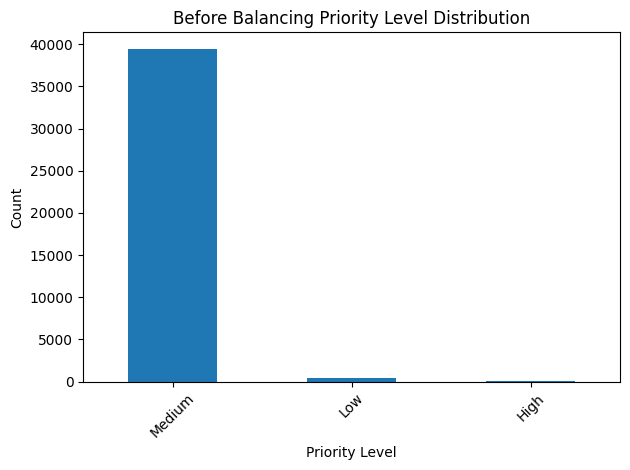

In [5]:
import matplotlib.pyplot as plt

email_data['Email_Priority'].value_counts().plot(kind='bar', title='Before Balancing Priority Level Distribution')
plt.xlabel('Priority Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
email_data.columns

Index(['From', 'To', 'Subject', 'Message', 'Day', 'Date & Time', 'url_count',
       'Cleaned_Subject', 'Cleaned_Message', 'Combined_Text', 'Subject_LLM',
       'Message_LLM', 'Email_Priority'],
      dtype='object')

In [5]:
email_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   From             40000 non-null  object
 1   To               37817 non-null  object
 2   Subject          40000 non-null  object
 3   Message          40000 non-null  object
 4   Day              40000 non-null  object
 5   Date & Time      40000 non-null  object
 6   url_count        40000 non-null  int64 
 7   Cleaned_Subject  39155 non-null  object
 8   Cleaned_Message  39887 non-null  object
 9   Combined_Text    40000 non-null  object
 10  Subject_LLM      39953 non-null  object
 11  Message_LLM      39976 non-null  object
 12  Email_Priority   40000 non-null  object
dtypes: int64(1), object(12)
memory usage: 4.0+ MB


In [8]:
email_data["Email_Priority"].value_counts()

Email_Priority
Medium    39432
Low         455
High        113
Name: count, dtype: int64

Extremely Imbalance: High 113, Low 455, Medium 39432

Word Cloud for ML

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(email_data['Combined_Text'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.show()

Word Cloud for DL

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

subject_text = ' '.join(email_data['Subject_LLM'].dropna())
message_text = ' '.join(email_data['Message_LLM'].dropna())

combined_text = subject_text + ' ' + message_text

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.show()

ML Cleaned Text Top words Count - Unigram

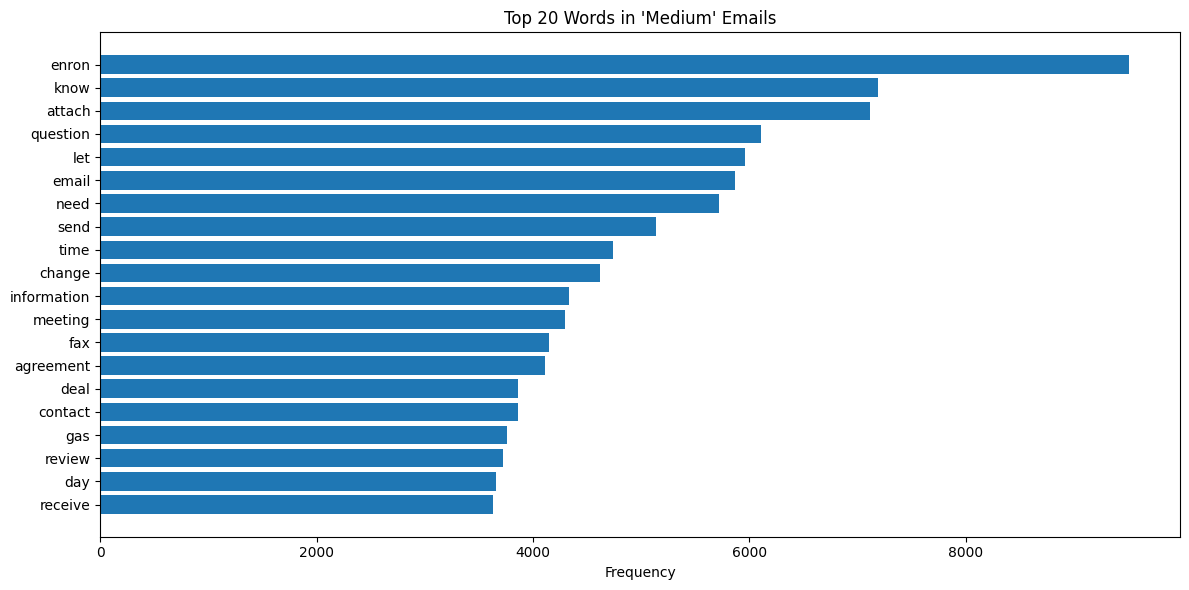

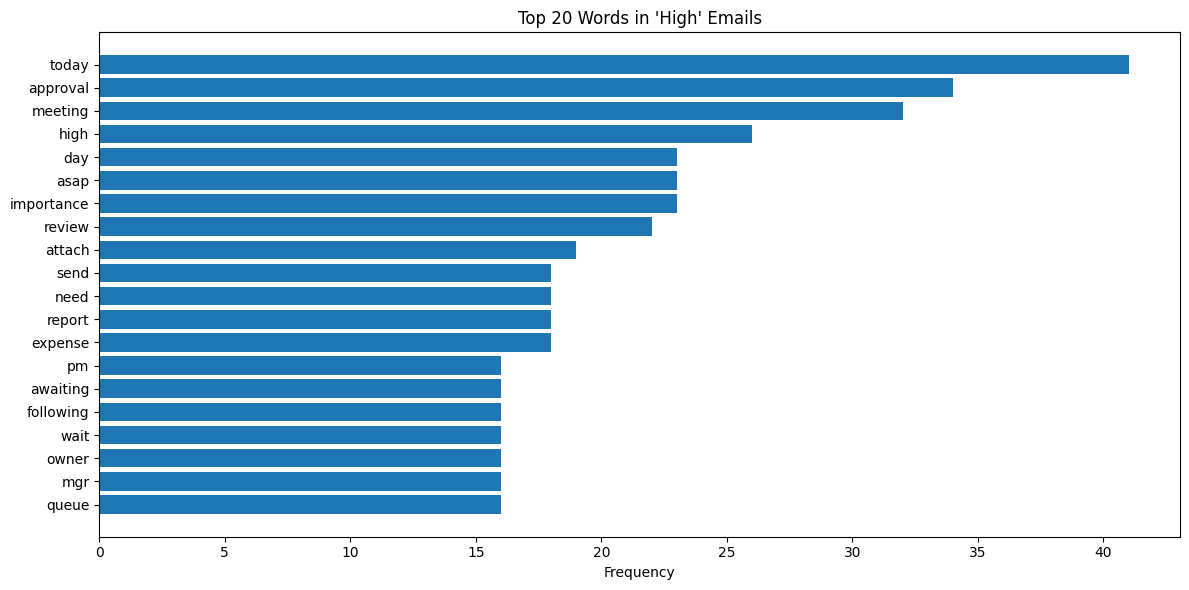

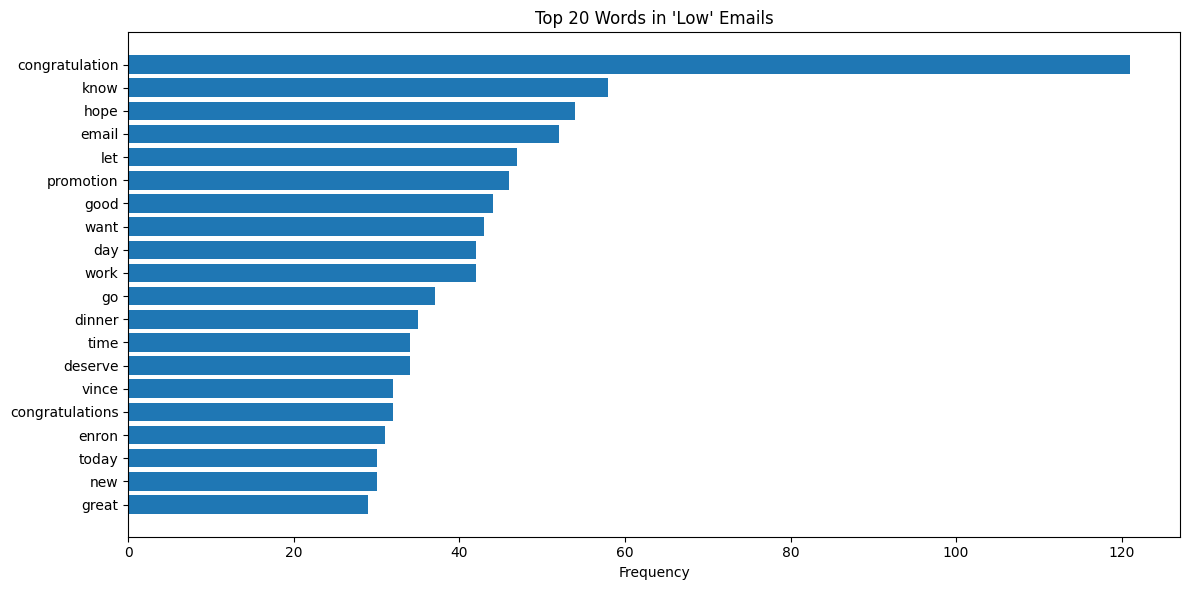

In [5]:
from collections import Counter
import matplotlib.pyplot as plt

categories = email_data['Email_Priority'].unique()

for category in categories:
    category_emails = email_data[email_data['Email_Priority'] == category]
    
    text = " ".join(str(msg) for msg in category_emails['Combined_Text'].dropna())
    words = text.split()
    
    word_freq = Counter(words)
    top_words = word_freq.most_common(20)
    
    if not top_words:
        continue

    labels, values = zip(*top_words)

    plt.figure(figsize=(12, 6))
    plt.barh(labels, values)
    plt.xlabel("Frequency")
    plt.title(f"Top 20 Words in '{category}' Emails")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

🔍 In Cleaned Text "Combined_Text" shows - Unigram
1) High Priority - Frequent words like today, approval, asap, and report show that these emails are focused on urgent updates, approvals, and immediate actions.

2) Medium Priority - Words such as enron, attach, agreement, meeting, and information suggest these emails handle routine operations, documents, and coordination.

3)  Low Priority - The use of words like congratulation, hope, promotion, and dinner reflects informal, social emails related to celebrations and casual updates.

<Figure size 1200x600 with 0 Axes>

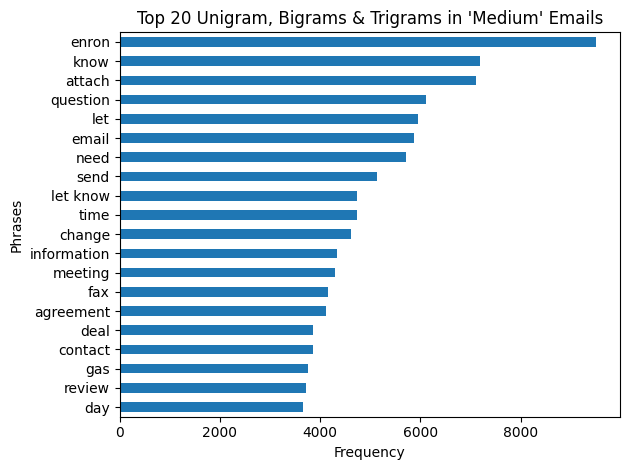

<Figure size 1200x600 with 0 Axes>

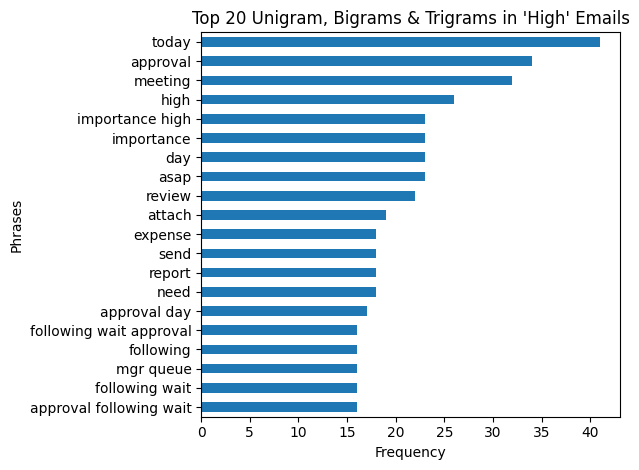

<Figure size 1200x600 with 0 Axes>

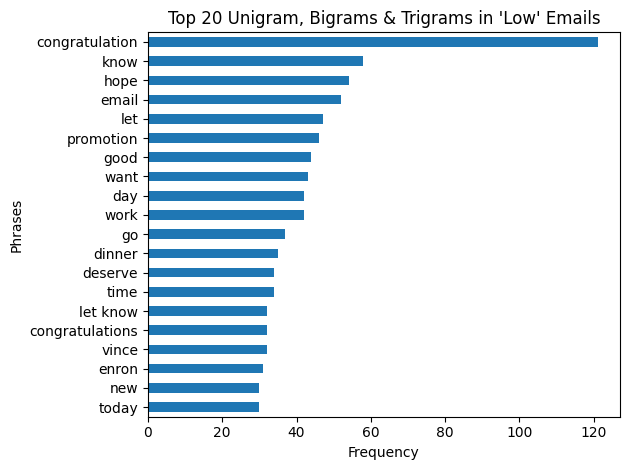

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import pandas as pd

categories = email_data['Email_Priority'].unique()

for category in categories:
    category_emails = email_data[email_data['Email_Priority'] == category]
    
    text_data = category_emails['Combined_Text'].dropna().astype(str).tolist()

    # Use CountVectorizer for bigrams and trigrams
    vectorizer = CountVectorizer(ngram_range=(1, 3))  # bigrams and trigrams
    X = vectorizer.fit_transform(text_data)

    # Fix: transpose the sum to get correct shape
    word_freq = pd.DataFrame(X.sum(axis=0).T, columns=["frequency"], index=vectorizer.get_feature_names_out())

    top_ngrams = word_freq.sort_values("frequency", ascending=False).head(20)

    if top_ngrams.empty:
        continue

    plt.figure(figsize=(12, 6))
    top_ngrams.sort_values("frequency").plot(kind="barh", legend=False)
    plt.title(f"Top 20 Unigram, Bigrams & Trigrams in '{category}' Emails")
    plt.xlabel("Frequency")
    plt.ylabel("Phrases")
    plt.tight_layout()
    plt.show()

✅ The use of unigrams, bigrams, and trigrams allows deeper insight into the context and intent behind each email. While unigrams highlight general topics (e.g., approval, congratulation), bigrams and trigrams capture meaningful phrases (e.g., let know, approval following wait) that reveal urgency, formality, or social tone. This richer representation helps distinguish priority levels more accurately, making n-gram analysis an effective feature engineering strategy for email classification and prioritization.

Average Sentiment Analysis for each category

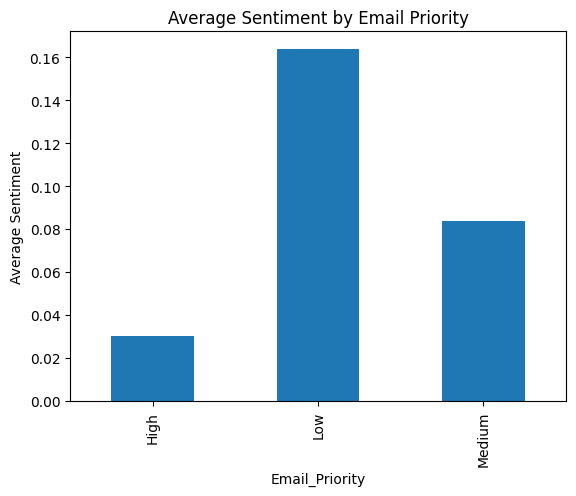

In [6]:
from textblob import TextBlob

# Function to calculate sentiment
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply sentiment analysis to the email content
email_data['sentiment'] = email_data['Combined_Text'].apply(get_sentiment)

# Group by Email_Priority and calculate average sentiment
sentiment_analysis = email_data.groupby('Email_Priority')['sentiment'].mean()

# Plotting the average sentiment
sentiment_analysis.plot(kind='bar', title='Average Sentiment by Email Priority')
plt.ylabel('Average Sentiment')
plt.show()

✅ The graph shows a clear relationship between email sentiment and priority level with lower sentiment scores in high-priority emails and higher positivity in low-priority emails supporting the idea that email tone can reflect urgency and intent.

1) Low Priority: High sentiment score aligns with earlier n-gram analysis (congratulation, hope, good), confirming these are often friendly, celebratory, or informal.

2) Medium Priority: Balanced sentiment aligns with routine business communication—neutral and task-oriented, neither overly positive nor negative.

3) High Priority: Lower sentiment likely reflects urgent or stressful communication using words like asap, approval, wait, which carry pressure or demand.

C:\Users\User\AppData\Local\Temp\ipykernel_15300\79036674.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sentiment = email_data.resample('M')['sentiment'].mean()


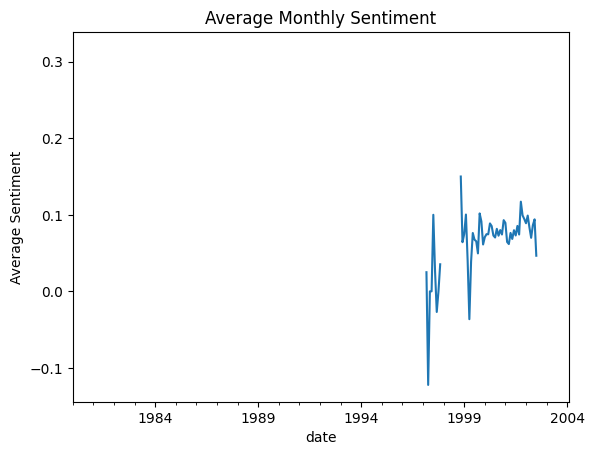

In [10]:
# Example: Analyzing sentiment over time
email_data['date'] = pd.to_datetime(email_data['Date & Time'])  # Replace with your date column
email_data.set_index('date', inplace=True)

# Resampling to get average sentiment by month
monthly_sentiment = email_data.resample('M')['sentiment'].mean()

# Plotting the trend
monthly_sentiment.plot(title='Average Monthly Sentiment')
plt.ylabel('Average Sentiment')
plt.show()

🚫 Although the chart displays average sentiment over time, the result is likely unreliable due to partial or filtered data and the analysis being focused on content rather than chronology. For meaningful time-based sentiment trends, a complete and balanced timestamped dataset is essential.

# Model Building Test

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split

# Combine text columns if needed
text_data = email_data['Combined_Text']  # or use other text columns like 'Subject', 'Message'

# Vectorize the text data using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # Adjust max_features as needed
X_tfidf = tfidf_vectorizer.fit_transform(text_data)

# Convert to DataFrame for compatibility with SelectKBest
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Separate target variable
y = email_data['Email_Priority']

# Apply SelectKBest with chi2
chi2_selector = SelectKBest(chi2, k=50)  # Select top 50 features
X_selected = chi2_selector.fit_transform(X_tfidf_df, y)

# Get selected feature names
selected_features = X_tfidf_df.columns[chi2_selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['approval', 'asap', 'brent', 'christmas', 'congratulation', 'day',
       'deadline', 'dinner', 'energy', 'evening', 'expense', 'family',
       'following', 'gas', 'go', 'good', 'great', 'happy', 'hey', 'hi', 'high',
       'holiday', 'hope', 'immediately', 'importance', 'little', 'love',
       'lunch', 'meeting', 'night', 'noon', 'owner', 'power', 'priority',
       'reminder', 'report', 'review', 'sally', 'see', 'solution', 'stay',
       'subject', 'today', 'tonight', 'vacation', 'vince', 'wait', 'weekend',
       'well', 'wish'],
      dtype='object')


In [7]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test set
y_pred = lr_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.98725
Classification Report:
               precision    recall  f1-score   support

        High       0.00      0.00      0.00        21
         Low       0.58      0.13      0.21        84
      Medium       0.99      1.00      0.99      7895

    accuracy                           0.99      8000
   macro avg       0.52      0.38      0.40      8000
weighted avg       0.98      0.99      0.98      8000



C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.

In [11]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {'C': [0.1, 1, 10, 100]}

# Initialize Grid Search
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 100}


In [12]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_selected, y)

# Check the new class distribution
print("Resampled class distribution:")
print(y_resampled.value_counts())

Resampled class distribution:
Email_Priority
Medium    39432
High      39432
Low       39432
Name: count, dtype: int64


In [13]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [14]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {'C': [0.1, 1, 10, 100]}

# Initialize Grid Search
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 100}


In [15]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
scores = cross_val_score(lr_model, X_selected, y, cv=5)
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())

Cross-validation scores: [0.81875  0.82125  0.783875 0.836    0.748375]
Mean cross-validation score: 0.8016500000000001


In [16]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test set
y_pred = lr_model.predict(X_test)

# Evaluate the model
print("Accuracy (Logistic Regression):", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy (Logistic Regression): 0.7875
Classification Report:
               precision    recall  f1-score   support

        High       0.03      0.86      0.05        21
         Low       0.05      0.63      0.09        84
      Medium       1.00      0.79      0.88      7895

    accuracy                           0.79      8000
   macro avg       0.36      0.76      0.34      8000
weighted avg       0.98      0.79      0.87      8000



In [24]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution
param_dist = {'C': [0.01, 0.1, 1, 10, 100, 1000]}

# Initialize Randomized Search
random_search = RandomizedSearchCV(LogisticRegression(max_iter=1000), param_dist, n_iter=10, cv=5, random_state=42)

# Fit Randomized Search
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters: {'C': 100}


In [20]:
# Example new user input
new_text = ["Urgent Assistance Required on Project Issue Hi Mr.Lee, I hope you are doing well. I am writing to inform you of an urgent issue regarding the website launch scheduled for tomorrow. Currently, the homepage is not loading properly due to a server configuration error. I would appreciate your immediate guidance on how to proceed. Please let me know if you are available for a quick discussion or if I should escalate this to the IT team. Thank you for your prompt attention. Best regards,"]

# Step 1: TF-IDF transform the new text
new_text_tfidf = tfidf_vectorizer.transform(new_text)  # Same vectorizer you trained earlier

# Step 2: Convert to DataFrame (to match SelectKBest input)
new_text_tfidf_df = pd.DataFrame(new_text_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Step 3: Select top 50 features using trained chi2_selector
new_text_selected = chi2_selector.transform(new_text_tfidf_df)

# Step 4: Predict
predicted_priority = lr_model.predict(new_text_selected)
predicted_proba = lr_model.predict_proba(new_text_selected)

# Step 5: Show result
print("Predicted Priority:", predicted_priority[0])
print("Prediction Probabilities:", predicted_proba)


Predicted Priority: Low
Prediction Probabilities: [[0.09023245 0.56463411 0.34513344]]


# Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the Random Forest model
y_rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf_pred))

Random Forest Accuracy: 0.98325
Random Forest Classification Report:
               precision    recall  f1-score   support

        High       0.14      0.10      0.11        21
         Low       0.31      0.19      0.24        84
      Medium       0.99      0.99      0.99      7895

    accuracy                           0.98      8000
   macro avg       0.48      0.43      0.45      8000
weighted avg       0.98      0.98      0.98      8000



In [22]:
# Example new user input
new_text = ["Urgent: Assistance Required on Project Issue Hi Mr.Lee, I hope you are doing well. I am writing to inform you of an urgent issue regarding the website launch scheduled for tomorrow. Currently, the homepage is not loading properly due to a server configuration error. I would appreciate your immediate guidance on how to proceed. Please let me know if you are available for a quick discussion or if I should escalate this to the IT team. Thank you for your prompt attention. Best regards,"]

# Step 1: TF-IDF transform the new text
new_text_tfidf = tfidf_vectorizer.transform(new_text)  # Same vectorizer you trained earlier

# Step 2: Convert to DataFrame (to match SelectKBest input)
new_text_tfidf_df = pd.DataFrame(new_text_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Step 3: Select top 50 features using trained chi2_selector
new_text_selected = chi2_selector.transform(new_text_tfidf_df)

# Step 4: Predict
predicted_priority = rf_model.predict(new_text_selected)
predicted_proba = rf_model.predict_proba(new_text_selected)

# Step 5: Show result
print("Predicted Priority:", predicted_priority[0])
print("Prediction Probabilities:", predicted_proba)

Predicted Priority: Medium
Prediction Probabilities: [[0. 0. 1.]]


# 2 Hybrid Model

In [23]:
from sklearn.ensemble import VotingClassifier

# Create an ensemble of models
ensemble_model = VotingClassifier(estimators=[
    ('lr', rf_model),
    ('rf', rf_model)
], voting='soft')

# Train the ensemble model
ensemble_model.fit(X_train, y_train)

# Evaluate the ensemble model
y_ensemble_pred = ensemble_model.predict(X_test)
print("Ensemble Accuracy:", accuracy_score(y_test, y_ensemble_pred))
print("Ensemble Classification Report:\n", classification_report(y_test, y_ensemble_pred))

Ensemble Accuracy: 0.98325
Ensemble Classification Report:
               precision    recall  f1-score   support

        High       0.14      0.10      0.11        21
         Low       0.31      0.19      0.24        84
      Medium       0.99      0.99      0.99      7895

    accuracy                           0.98      8000
   macro avg       0.48      0.43      0.45      8000
weighted avg       0.98      0.98      0.98      8000



In [24]:
# Example new user input
new_text = ["Urgent: Assistance Required on Project Issue Hi Mr.Lee, I hope you are doing well. I am writing to inform you of an urgent issue regarding the website launch scheduled for tomorrow. Currently, the homepage is not loading properly due to a server configuration error. I would appreciate your immediate guidance on how to proceed. Please let me know if you are available for a quick discussion or if I should escalate this to the IT team. Thank you for your prompt attention. Best regards,"]

# Step 1: TF-IDF transform the new text
new_text_tfidf = tfidf_vectorizer.transform(new_text)  # Same vectorizer you trained earlier

# Step 2: Convert to DataFrame (to match SelectKBest input)
new_text_tfidf_df = pd.DataFrame(new_text_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Step 3: Select top 50 features using trained chi2_selector
new_text_selected = chi2_selector.transform(new_text_tfidf_df)

# Step 4: Predict
predicted_priority = ensemble_model.predict(new_text_selected)
predicted_proba = ensemble_model.predict_proba(new_text_selected)

# Step 5: Show result
print("Predicted Priority:", predicted_priority[0])
print("Prediction Probabilities:", predicted_proba)

Predicted Priority: Medium
Prediction Probabilities: [[0. 0. 1.]]


In [25]:
from imblearn.combine import SMOTETomek

# Apply SMOTETomek
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_selected, y)

# Check the new class distribution
print("Resampled class distribution:")
print(y_resampled.value_counts())

Resampled class distribution:
Email_Priority
High      38539
Low       38207
Medium    37976
Name: count, dtype: int64


In [26]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest model with class weights
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Evaluate the Random Forest model
y_rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf_pred))

Random Forest Accuracy: 0.982375
Random Forest Classification Report:
               precision    recall  f1-score   support

        High       0.23      0.33      0.27        21
         Low       0.30      0.17      0.21        84
      Medium       0.99      0.99      0.99      7895

    accuracy                           0.98      8000
   macro avg       0.50      0.50      0.49      8000
weighted avg       0.98      0.98      0.98      8000



In [27]:
# Example new user input
new_text = ["Urgent: Assistance Required on Project Issue Hi Mr.Lee, I hope you are doing well. I am writing to inform you of an urgent issue regarding the website launch scheduled for tomorrow. Currently, the homepage is not loading properly due to a server configuration error. I would appreciate your immediate guidance on how to proceed. Please let me know if you are available for a quick discussion or if I should escalate this to the IT team. Thank you for your prompt attention. Best regards,"]

# Step 1: TF-IDF transform the new text
new_text_tfidf = tfidf_vectorizer.transform(new_text)  # Same vectorizer you trained earlier

# Step 2: Convert to DataFrame (to match SelectKBest input)
new_text_tfidf_df = pd.DataFrame(new_text_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Step 3: Select top 50 features using trained chi2_selector
new_text_selected = chi2_selector.transform(new_text_tfidf_df)

# Step 4: Predict
predicted_priority = rf_model.predict(new_text_selected)
predicted_proba = rf_model.predict_proba(new_text_selected)

# Step 5: Show result
print("Predicted Priority:", predicted_priority[0])
print("Prediction Probabilities:", predicted_proba)

Predicted Priority: Medium
Prediction Probabilities: [[0. 0. 1.]]


In [ ]:
from skopt import BayesSearchCV

# Define the parameter search space
param_space = {
    'n_estimators': (10, 1000),
    'max_depth': (1, 50),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 20)
}

# Initialize Bayesian Search
bayes_search = BayesSearchCV(RandomForestClassifier(random_state=42), param_space, n_iter=32, cv=5, random_state=42)

# Fit Bayesian Search
bayes_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", bayes_search.best_params_)

In [31]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # y is your original email_data['Email_Priority']

# Now re-split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_encoded, test_size=0.2, random_state=42)

# Then train XGBoost
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Predict
y_xgb_pred = xgb_model.predict(X_test)

# If you want to convert prediction back to text:
y_xgb_pred_labels = label_encoder.inverse_transform(y_xgb_pred)

# Evaluate
print("XGBoost Accuracy:", accuracy_score(y_test, y_xgb_pred))
print("XGBoost Classification Report:\n", classification_report(y_test, y_xgb_pred))

XGBoost Accuracy: 0.987
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.19      0.26        21
           1       0.55      0.20      0.30        84
           2       0.99      1.00      0.99      7895

    accuracy                           0.99      8000
   macro avg       0.65      0.46      0.52      8000
weighted avg       0.98      0.99      0.98      8000



In [33]:
# Example new user input
new_text = ["Urgent: Assistance Required on Project Issue Hi Mr.Lee, I hope you are doing well. I am writing to inform you of an urgent issue regarding the website launch scheduled for tomorrow. Currently, the homepage is not loading properly due to a server configuration error. I would appreciate your immediate guidance on how to proceed. Please let me know if you are available for a quick discussion or if I should escalate this to the IT team. Thank you for your prompt attention. Best regards,"]

# Step 1: TF-IDF transform the new text
new_text_tfidf = tfidf_vectorizer.transform(new_text)  # Same vectorizer you trained earlier

# Step 2: Convert to DataFrame (to match SelectKBest input)
new_text_tfidf_df = pd.DataFrame(new_text_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Step 3: Select top 50 features using trained chi2_selector
new_text_selected = chi2_selector.transform(new_text_tfidf_df)

# Step 4: Predict using XGBoost
predicted_priority = xgb_model.predict(new_text_selected)
predicted_proba = xgb_model.predict_proba(new_text_selected)

# Step 5: Show result
print("Predicted Priority:", predicted_priority[0])
print("Prediction Probabilities:", predicted_proba)

Predicted Priority: 2
Prediction Probabilities: [[1.4842142e-04 2.5919802e-03 9.9725962e-01]]


In [ ]:
from sklearn.ensemble import StackingClassifier

# Create a stacking ensemble of models
stacking_model = StackingClassifier(estimators=[
    ('lr', lr_model),
    ('rf', rf_model),
    ('xgb', xgb_model)
], final_estimator=LogisticRegression())

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Evaluate the stacking model
y_stacking_pred = stacking_model.predict(X_test)
print("Stacking Accuracy:", accuracy_score(y_test, y_stacking_pred))
print("Stacking Classification Report:\n", classification_report(y_test, y_stacking_pred))

Stacking Accuracy: 0.9875
Stacking Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        21
           1       0.65      0.20      0.31        84
           2       0.99      1.00      0.99      7895

    accuracy                           0.99      8000
   macro avg       0.55      0.40      0.43      8000
weighted avg       0.98      0.99      0.98      8000



In [34]:
# Example new user input
new_text = ["Urgent: Assistance Required on Project Issue Hi Mr.Lee, I hope you are doing well. I am writing to inform you of an urgent issue regarding the website launch scheduled for tomorrow. Currently, the homepage is not loading properly due to a server configuration error. I would appreciate your immediate guidance on how to proceed. Please let me know if you are available for a quick discussion or if I should escalate this to the IT team. Thank you for your prompt attention. Best regards,"]

# Step 1: TF-IDF transform the new text
new_text_tfidf = tfidf_vectorizer.transform(new_text)  # Same vectorizer you trained earlier

# Step 2: Convert to DataFrame (to match SelectKBest input)
new_text_tfidf_df = pd.DataFrame(new_text_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Step 3: Select top 50 features using trained chi2_selector
new_text_selected = chi2_selector.transform(new_text_tfidf_df)

# Step 4: Predict using XGBoost
predicted_priority = stacking_model.predict(new_text_selected)
predicted_proba = stacking_model.predict_proba(new_text_selected)

# Step 5: Show result
print("Predicted Priority:", predicted_priority[0])
print("Prediction Probabilities:", predicted_proba)

Predicted Priority: 2
Prediction Probabilities: [[0.00115591 0.0174626  0.98138148]]


In [36]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Use stratified kfold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create stacking model
stacking_model = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(class_weight='balanced', max_iter=5000)),
        ('rf', RandomForestClassifier(class_weight='balanced', random_state=42)),
        ('xgb', XGBClassifier(random_state=42))  # you can add scale_pos_weight for XGB if needed
    ],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=5000),
    cv=skf,
    n_jobs=-1
)

# Train on SMOTE balanced data
stacking_model.fit(X_train, y_train)

# Predict
y_pred = stacking_model.predict(X_test)
print("Stacking Accuracy:", accuracy_score(y_test, y_pred))
print("Stacking Macro F1 Score:", f1_score(y_test, y_pred, average='macro'))
print("Stacking Classification Report:\n", classification_report(y_test, y_pred))

Stacking Accuracy: 0.827125
Stacking Macro F1 Score: 0.359702722980544
Stacking Classification Report:
               precision    recall  f1-score   support

           0       0.03      0.86      0.05        21
           1       0.07      0.62      0.12        84
           2       1.00      0.83      0.90      7895

    accuracy                           0.83      8000
   macro avg       0.36      0.77      0.36      8000
weighted avg       0.98      0.83      0.89      8000



In [37]:
# === Step 1: Import everything you need ===
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTEENN  # 🚀 New: use SMOTEENN
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# === Step 2: Preprocessing ===
text_data = email_data['Combined_Text']
y = email_data['Email_Priority']

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(text_data)
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Feature Selection
chi2_selector = SelectKBest(chi2, k=50)
X_selected = chi2_selector.fit_transform(X_tfidf_df, y_encoded)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# === Step 3: Resampling using SMOTEENN ===
smoteenn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smoteenn.fit_resample(X_train, y_train)

# === Step 4: Define Models with Manual Class Weights ===
rf_model = RandomForestClassifier(class_weight={0: 10, 1: 5, 2: 1}, random_state=42)
lr_model = LogisticRegression(class_weight={0: 10, 1: 5, 2: 1}, max_iter=5000)
xgb_model = XGBClassifier(scale_pos_weight=5, random_state=42)  # Small boost for imbalance

# === Step 5: Define Stacking with StratifiedKFold ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stacking_model = StackingClassifier(
    estimators=[
        ('lr', lr_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    final_estimator=LogisticRegression(class_weight={0: 10, 1: 5, 2: 1}, max_iter=5000),
    cv=skf,
    n_jobs=-1
)

# === Step 6: Train ===
stacking_model.fit(X_train_resampled, y_train_resampled)

# === Step 7: Predict and Evaluate ===
y_pred = stacking_model.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred))
print("Stacking Macro F1 Score:", f1_score(y_test, y_pred, average='macro'))
print("Stacking Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Stacking Accuracy: 0.925125
Stacking Macro F1 Score: 0.4031188992505799
Stacking Classification Report:
               precision    recall  f1-score   support

        High       0.05      0.57      0.09        23
         Low       0.10      0.35      0.16        91
      Medium       0.99      0.93      0.96      7886

    accuracy                           0.93      8000
   macro avg       0.38      0.62      0.40      8000
weighted avg       0.98      0.93      0.95      8000



In [39]:
# Example weight grid to search
weight_options = [
    {0: 1, 1: 1, 2: 1},
    {0: 5, 1: 2, 2: 1},
    {0: 10, 1: 5, 2: 1},
    {0: 20, 1: 10, 2: 1},
    {0: 30, 1: 15, 2: 1},
]

In [40]:
best_f1 = 0
best_weights = None

for weights in weight_options:
    print(f"Testing weights: {weights}")
    
    # Define models
    rf_model = RandomForestClassifier(class_weight=weights, random_state=42)
    lr_model = LogisticRegression(class_weight=weights, max_iter=5000)
    xgb_model = XGBClassifier(random_state=42)

    stacking_model = StackingClassifier(
        estimators=[
            ('lr', lr_model),
            ('rf', rf_model),
            ('xgb', xgb_model)
        ],
        final_estimator=LogisticRegression(class_weight=weights, max_iter=5000),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1
    )

    # Train
    stacking_model.fit(X_train_resampled, y_train_resampled)

    # Predict
    y_pred = stacking_model.predict(X_test)

    # Evaluate
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    print(f"Macro F1 Score: {macro_f1:.4f}")
    
    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_weights = weights
        
print("\n🏆 Best Weights Found:", best_weights)
print("🏆 Best Macro F1 Score:", best_f1)

Testing weights: {0: 1, 1: 1, 2: 1}
Macro F1 Score: 0.3977
Testing weights: {0: 5, 1: 2, 2: 1}
Macro F1 Score: 0.4011
Testing weights: {0: 10, 1: 5, 2: 1}
Macro F1 Score: 0.4031
Testing weights: {0: 20, 1: 10, 2: 1}
Macro F1 Score: 0.3969
Testing weights: {0: 30, 1: 15, 2: 1}
Macro F1 Score: 0.3992

🏆 Best Weights Found: {0: 10, 1: 5, 2: 1}
🏆 Best Macro F1 Score: 0.4031188992505799


In [41]:
# Final model
rf_model = RandomForestClassifier(class_weight={0: 10, 1: 5, 2: 1}, random_state=42)
lr_model = LogisticRegression(class_weight={0: 10, 1: 5, 2: 1}, max_iter=5000)
xgb_model = XGBClassifier(random_state=42)

stacking_model = StackingClassifier(
    estimators=[
        ('lr', lr_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    final_estimator=LogisticRegression(class_weight={0: 10, 1: 5, 2: 1}, max_iter=5000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

# Train
stacking_model.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred = stacking_model.predict(X_test)

# Evaluate
print("Final Stacking Accuracy:", accuracy_score(y_test, y_pred))
print("Final Stacking Macro F1 Score:", f1_score(y_test, y_pred, average='macro'))
print("Final Stacking Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Final Stacking Accuracy: 0.925125
Final Stacking Macro F1 Score: 0.4031188992505799
Final Stacking Classification Report:
               precision    recall  f1-score   support

        High       0.05      0.57      0.09        23
         Low       0.10      0.35      0.16        91
      Medium       0.99      0.93      0.96      7886

    accuracy                           0.93      8000
   macro avg       0.38      0.62      0.40      8000
weighted avg       0.98      0.93      0.95      8000



In [45]:
# User email input
new_text = ["Urgent Assistance Required on Project Issue Hi Mr.Lee, I hope you are doing well. I am writing to inform you of an urgent issue regarding the website launch scheduled for tomorrow. Currently, the homepage is not loading properly due to a server configuration error. I would appreciate your immediate guidance on how to proceed. Please let me know if you are available for a quick discussion or if I should escalate this to the IT team. Thank you for your prompt attention. Best regards,"]

# Step 1: TF-IDF Transform
new_text_tfidf = tfidf_vectorizer.transform(new_text)

# Step 2: Convert to DataFrame
new_text_tfidf_df = pd.DataFrame(new_text_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Step 3: Feature Selection
new_text_selected = chi2_selector.transform(new_text_tfidf_df)

# Step 4: Predict
predicted_priority = stacking_model.predict(new_text_selected)
predicted_proba = stacking_model.predict_proba(new_text_selected)

# Step 5: Decode Prediction
predicted_label = label_encoder.inverse_transform(predicted_priority)[0]

# Step 6: Show Result
print("Predicted Priority Label:", predicted_label)
print("Prediction Probabilities:", predicted_proba)

Predicted Priority Label: Medium
Prediction Probabilities: [[4.13855767e-04 9.10192955e-04 9.98675951e-01]]


In [60]:
def predict_priority_2stage(text, model, tfidf_vectorizer, chi2_selector, label_encoder,
                             urgent_keywords=None, urgent_force=True, high_priority_threshold=0.002):
    """
    2-Stage Priority Prediction System:
    Stage 1: Detect urgency based on urgent keywords.
    Stage 2: If urgent, force High Priority (or let model predict if not urgent).
    
    Parameters:
    - text: str or list[str] (email text)
    - model: trained stacking model
    - tfidf_vectorizer: fitted TF-IDF vectorizer
    - chi2_selector: fitted SelectKBest
    - label_encoder: fitted LabelEncoder
    - urgent_keywords: list of urgent words (optional)
    - urgent_force: bool, whether to force 'High' if urgent detected
    - high_priority_threshold: float, probability threshold for High Priority (backup)
    
    Returns:
    - predicted_label: str
    - predicted_proba: list
    """
    import pandas as pd

    if isinstance(text, str):
        text = [text]

    # Default urgent keywords list if not provided
    if urgent_keywords is None:
        urgent_keywords = ["urgent", "immediate", "critical", "important", "asap", "escalate", "deadline", "attention", "emergency"]

    # Step 1: Urgent keyword detection (text-based)
    text_lower = text[0].lower()
    urgent_detected = any(word in text_lower for word in urgent_keywords)

    # Step 2: Model prediction
    text_tfidf = tfidf_vectorizer.transform(text)
    text_tfidf_df = pd.DataFrame(text_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
    text_selected = chi2_selector.transform(text_tfidf_df)

    predicted_priority = model.predict(text_selected)
    predicted_proba = model.predict_proba(text_selected)

    # Step 3: Final Decision Logic
    high_proba = predicted_proba[0][0]  # probability for High Priority class

    if urgent_detected and urgent_force:
        # Force High if urgent word detected
        predicted_label = 'High'
    elif high_proba > high_priority_threshold:
        # If model High probability is strong enough
        predicted_label = 'High'
    else:
        # Otherwise trust model
        predicted_label = label_encoder.inverse_transform(predicted_priority)[0]

    return predicted_label, predicted_proba[0]

email_text = "Hi bye bye"

predicted_label, predicted_proba = predict_priority_2stage(
    text=email_text,
    model=stacking_model,
    tfidf_vectorizer=tfidf_vectorizer,
    chi2_selector=chi2_selector,
    label_encoder=label_encoder,
    urgent_force=True,          # force High if urgent detected
    high_priority_threshold=0.002  # backup threshold if needed
)

print("Predicted Priority:", predicted_label)
print("Prediction Probabilities:", predicted_proba)

Predicted Priority: Medium
Prediction Probabilities: [8.30058327e-04 1.67255020e-01 8.31914922e-01]
